<a href="https://colab.research.google.com/github/HeshanNavindu-7/oilspill-reseach/blob/main/Random_Forest_trajectory_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
from datetime import datetime, timezone, timedelta
from getpass import getpass

import tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

CSV_PATH = "/content/drive/MyDrive/Oil Spill/Dataset Cretaion /LSTM Data/oil_spill_expanded_trajectory_dataset_FILLED.csv"

df = pd.read_csv(CSV_PATH)

print("Rows:", len(df))
print("Columns:", len(df.columns))
display(df.head())

Rows: 39
Columns: 46


,scenario_id,repeat_id,image_name,image_path,predicted_mask_path,oil_status,centroid_x,centroid_y,area_pixels,area_ratio,...,swell_u,swell_v,total_drift_u,total_drift_v,east_movement_m,north_movement_m,next_lat,next_lon,metocean_data_source,error
0,1,1,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,328.0,257.0,318656.0,0.777969,...,0.233315,-0.531003,0.020612,-0.112002,74.203775,-403.206557,28.841663,-88.358017,stormglass_api,NaN
1,2,2,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,328.0,257.0,318656.0,0.777969,...,0.211772,-0.518414,0.014887,-0.110828,53.592743,-398.979043,28.774446,-88.480256,stormglass_api,NaN
2,3,3,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,328.0,257.0,318656.0,0.777969,...,0.117616,-0.382317,-0.037868,-0.096699,-136.326026,-348.115948,28.745595,-88.453729,stormglass_api,NaN
3,4,1,3_jpg.rf.dcc0e833472d2dbe305cbfb9cd0c2e3a.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,229.0,202.0,31264.0,0.076328,...,0.181087,-0.487450,-0.059156,-0.127300,-212.962016,-458.279983,28.864937,-88.492847,stormglass_api,NaN
4,5,2,3_jpg.rf.dcc0e833472d2dbe305cbfb9cd0c2e3a.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,229.0,202.0,31264.0,0.076328,...,-0.087633,-0.338852,-0.026250,-0.144624,-94.498464,-520.646332,28.655807,-88.473181,sample_filled_after_api_limit,NaN


In [3]:
print("Missing values:")
display(df.isna().sum())

if "metocean_data_source" in df.columns:
    print("Metocean data source count:")
    display(df["metocean_data_source"].value_counts())

print("Oil status count:")
display(df["oil_status"].value_counts())

Missing values:


,0
scenario_id,0
repeat_id,0
image_name,0
image_path,0
predicted_mask_path,0
oil_status,0
centroid_x,0
centroid_y,0
area_pixels,0
area_ratio,0


Metocean data source count:


,count
metocean_data_source,
sample_filled_after_api_limit,35
stormglass_api,4


Oil status count:


,count
oil_status,
oil_spill_detected,39


In [4]:
feature_columns = [
    # spill mask/image features
    "centroid_x",
    "centroid_y",
    "area_pixels",
    "area_ratio",

    # current location
    "scene_lat",
    "scene_lon",

    # raw metocean features
    "wind_speed",
    "wind_direction",
    "current_speed",
    "current_direction",
    "wave_height",
    "wave_direction",
    "wave_period",
    "swell_height",
    "swell_direction",
    "swell_period",

    # vector features derived from speed + direction
    "wind_u",
    "wind_v",
    "current_u",
    "current_v",
    "wave_u",
    "wave_v",
    "swell_u",
    "swell_v"
]

target_columns = ["next_lat", "next_lon"]

# keep only columns that exist in your CSV
feature_columns = [col for col in feature_columns if col in df.columns]

print("Using feature columns:")
print(feature_columns)

print("Target columns:")
print(target_columns)

Using feature columns:
['centroid_x', 'centroid_y', 'area_pixels', 'area_ratio', 'scene_lat', 'scene_lon', 'wind_speed', 'wind_direction', 'current_speed', 'current_direction', 'wave_height', 'wave_direction', 'wave_period', 'swell_height', 'swell_direction', 'swell_period', 'wind_u', 'wind_v', 'current_u', 'current_v', 'wave_u', 'wave_v', 'swell_u', 'swell_v']
Target columns:
['next_lat', 'next_lon']


In [5]:
model_df = df.copy()

# Remove rows where target is missing
model_df = model_df.dropna(subset=target_columns)

# Fill missing input values
model_df[feature_columns] = model_df[feature_columns].fillna(0)

print("Final rows for model:", len(model_df))
display(model_df[feature_columns + target_columns].head())

Final rows for model: 39


,centroid_x,centroid_y,area_pixels,area_ratio,scene_lat,scene_lon,wind_speed,wind_direction,current_speed,current_direction,...,wind_u,wind_v,current_u,current_v,wave_u,wave_v,swell_u,swell_v,next_lat,next_lon
0,328.0,257.0,318656.0,0.777969,28.845292,-88.358779,2.12,103.88,0.02,111.97,...,-2.058097,0.508565,0.018548,-0.007482,0.269840,-0.444507,0.233315,-0.531003,28.841663,-88.358017
1,328.0,257.0,318656.0,0.777969,28.778037,-88.480806,3.25,114.89,0.05,129.30,...,-2.948132,1.367852,0.038692,-0.031669,0.289744,-0.455684,0.211772,-0.518414,28.774446,-88.480256
2,328.0,257.0,318656.0,0.777969,28.748728,-88.452329,4.26,127.89,0.07,175.06,...,-3.361955,2.616268,0.006028,-0.069740,0.301339,-0.448101,0.117616,-0.382317,28.745595,-88.453729
3,229.0,202.0,31264.0,0.076328,28.869062,-88.490658,4.05,133.04,0.10,200.67,...,-2.960053,2.764161,-0.035298,-0.093563,0.312235,-0.452780,0.181087,-0.487450,28.864937,-88.492847
4,229.0,202.0,31264.0,0.076328,28.660493,-88.472212,4.35,156.50,0.11,172.00,...,-1.734558,3.989211,0.015309,-0.108929,0.128276,-0.809904,-0.087633,-0.338852,28.655807,-88.473181


In [6]:
from sklearn.model_selection import GroupShuffleSplit

X = model_df[feature_columns].values
y = model_df[target_columns].values

groups = model_df["image_name"].values

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

train_df = model_df.iloc[train_idx]
test_df = model_df.iloc[test_idx]

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train images:", train_df["image_name"].nunique())
print("Test images:", test_df["image_name"].nunique())

print("Test image names:")
print(test_df["image_name"].unique())

Train rows: 27
Test rows: 12
Train images: 9
Test images: 4
Test image names:
['2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg'
 'Defense.gov_photo_essay_100506-N-6436W-023.jpg'
 'Skimming_Oil_in_Gulf_of_Mexico.jpg'
 '_____thumb_fed_photo_jpg.rf.9aeb1f79f20f1885c9ffaf3cf33b1774.jpg']


In [7]:
from sklearn.ensemble import RandomForestRegressor

trajectory_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

trajectory_model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred = trajectory_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Trajectory Model Evaluation")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

Trajectory Model Evaluation
MAE : 0.03859745776499872
RMSE: 0.05135330872935758
R2  : 0.52163067044691


In [9]:
import math

def haversine_distance_m(lat1, lon1, lat2, lon2):
    R = 6371000  # Earth radius in meters

    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    )

    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c


distance_errors = []

for actual, predicted in zip(y_test, pred):
    actual_lat, actual_lon = actual
    pred_lat, pred_lon = predicted

    dist_error = haversine_distance_m(
        actual_lat,
        actual_lon,
        pred_lat,
        pred_lon
    )

    distance_errors.append(dist_error)

distance_errors = np.array(distance_errors)

print("Distance Error Results")
print("Mean distance error:", distance_errors.mean(), "meters")
print("RMSE distance error:", np.sqrt(np.mean(distance_errors ** 2)), "meters")
print("Min distance error:", distance_errors.min(), "meters")
print("Max distance error:", distance_errors.max(), "meters")

Distance Error Results
Mean distance error: 6657.078951318603 meters
RMSE distance error: 7952.814003052021 meters
Min distance error: 469.52066183955174 meters
Max distance error: 14568.562643082561 meters


In [10]:
comparison_df = test_df[[
    "scenario_id",
    "image_name",
    "scene_lat",
    "scene_lon",
    "next_lat",
    "next_lon"
]].copy()

comparison_df["pred_next_lat"] = pred[:, 0]
comparison_df["pred_next_lon"] = pred[:, 1]

comparison_df["lat_error"] = abs(comparison_df["next_lat"] - comparison_df["pred_next_lat"])
comparison_df["lon_error"] = abs(comparison_df["next_lon"] - comparison_df["pred_next_lon"])
comparison_df["distance_error_m"] = distance_errors

display(comparison_df)

,scenario_id,image_name,scene_lat,scene_lon,next_lat,next_lon,pred_next_lat,pred_next_lon,lat_error,lon_error,distance_error_m
0,1,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg,28.845292,-88.358779,28.841663,-88.358017,28.739573,-88.316320,0.102090,0.041697,12057.189716
1,2,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg,28.778037,-88.480806,28.774446,-88.480256,28.778592,-88.481168,0.004146,0.000911,469.520662
2,3,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg,28.748728,-88.452329,28.745595,-88.453729,28.776080,-88.482689,0.030485,0.028960,4411.305555
24,25,Defense.gov_photo_essay_100506-N-6436W-023.jpg,28.786953,-88.332608,28.785734,-88.334192,28.734365,-88.310721,0.051369,0.023471,6153.143524
25,26,Defense.gov_photo_essay_100506-N-6436W-023.jpg,28.847316,-88.245393,28.846415,-88.247250,28.746131,-88.272344,0.100285,0.025094,11416.096748
26,27,Defense.gov_photo_essay_100506-N-6436W-023.jpg,28.809818,-88.334041,28.811377,-88.332897,28.735669,-88.309294,0.075708,0.023604,8727.019296
27,28,Skimming_Oil_in_Gulf_of_Mexico.jpg,28.648224,-88.452546,28.651527,-88.455308,28.675236,-88.479135,0.023709,0.023827,3514.908825
28,29,Skimming_Oil_in_Gulf_of_Mexico.jpg,28.792011,-88.252219,28.795756,-88.254411,28.744855,-88.275334,0.050901,0.020923,6016.118139
29,30,Skimming_Oil_in_Gulf_of_Mexico.jpg,28.875962,-88.277603,28.879310,-88.280643,28.748303,-88.278700,0.131007,0.001943,14568.562643
33,34,_____thumb_fed_photo_jpg.rf.9aeb1f79f20f1885c9...,28.628826,-88.363176,28.631590,-88.365534,28.652559,-88.345392,0.020969,0.020142,3049.607284


In [11]:
COMPARISON_CSV = "/content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/trajectory_prediction_comparison.csv"

comparison_df.to_csv(COMPARISON_CSV, index=False)

print("Comparison CSV saved:")
print(COMPARISON_CSV)

Comparison CSV saved:
/content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/trajectory_prediction_comparison.csv


In [12]:
import joblib

MODEL_PATH = "/content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/trajectory_random_forest_model.pkl"
FEATURE_COLUMNS_PATH = "/content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/trajectory_feature_columns.pkl"

joblib.dump(trajectory_model, MODEL_PATH)
joblib.dump(feature_columns, FEATURE_COLUMNS_PATH)

print("Model saved:", MODEL_PATH)
print("Feature columns saved:", FEATURE_COLUMNS_PATH)

Model saved: /content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/trajectory_random_forest_model.pkl
Feature columns saved: /content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/trajectory_feature_columns.pkl


In [13]:
importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": trajectory_model.feature_importances_
}).sort_values(by="importance", ascending=False)

display(importance_df)

,feature,importance
5,scene_lon,0.635936
4,scene_lat,0.211172
12,wave_period,0.016225
18,current_u,0.010523
6,wind_speed,0.010490
10,wave_height,0.009924
23,swell_v,0.009093
13,swell_height,0.008789
22,swell_u,0.007031
20,wave_u,0.006953


In [14]:
IMPORTANCE_CSV = "/content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/trajectory_feature_importance.csv"

importance_df.to_csv(IMPORTANCE_CSV, index=False)

print("Feature importance saved:")
print(IMPORTANCE_CSV)

Feature importance saved:
/content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/trajectory_feature_importance.csv


In [15]:
print("comparison_df exists:", "comparison_df" in globals())
print("importance_df exists:", "importance_df" in globals())
print("trajectory_model exists:", "trajectory_model" in globals())
print("feature_columns exists:", "feature_columns" in globals())

comparison_df exists: True
importance_df exists: True
trajectory_model exists: True
feature_columns exists: True


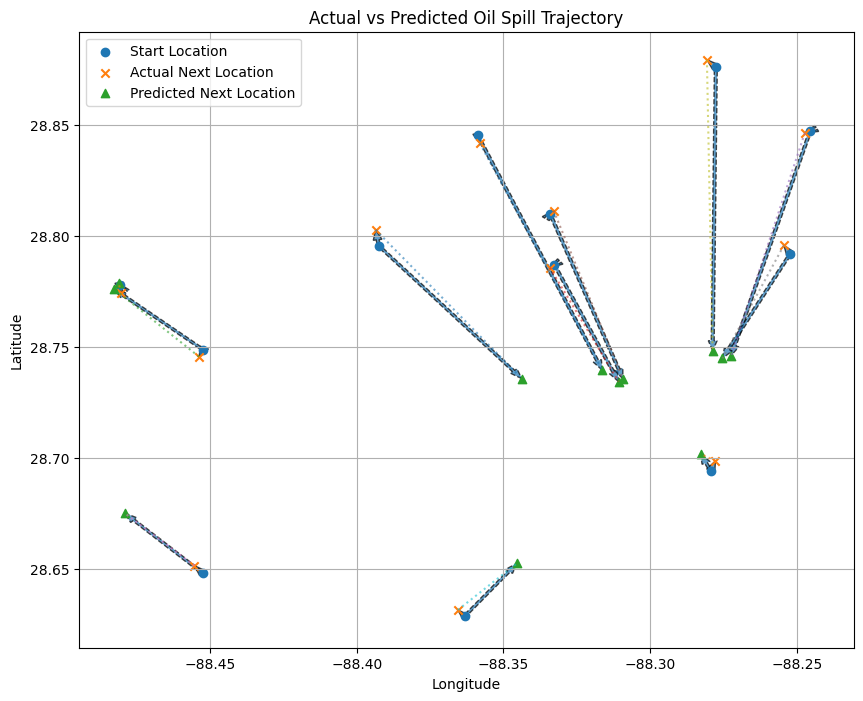

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))

for i, row in comparison_df.iterrows():
    # Start point
    start_lon = row["scene_lon"]
    start_lat = row["scene_lat"]

    # Actual next point
    actual_lon = row["next_lon"]
    actual_lat = row["next_lat"]

    # Predicted next point
    pred_lon = row["pred_next_lon"]
    pred_lat = row["pred_next_lat"]

    # Actual arrow
    plt.arrow(
        start_lon,
        start_lat,
        actual_lon - start_lon,
        actual_lat - start_lat,
        head_width=0.003,
        length_includes_head=True,
        alpha=0.7
    )

    # Predicted arrow
    plt.arrow(
        start_lon,
        start_lat,
        pred_lon - start_lon,
        pred_lat - start_lat,
        head_width=0.003,
        length_includes_head=True,
        alpha=0.7,
        linestyle="--"
    )

    # Error line between actual and predicted
    plt.plot(
        [actual_lon, pred_lon],
        [actual_lat, pred_lat],
        linestyle=":",
        alpha=0.6
    )

plt.scatter(
    comparison_df["scene_lon"],
    comparison_df["scene_lat"],
    marker="o",
    label="Start Location"
)

plt.scatter(
    comparison_df["next_lon"],
    comparison_df["next_lat"],
    marker="x",
    label="Actual Next Location"
)

plt.scatter(
    comparison_df["pred_next_lon"],
    comparison_df["pred_next_lat"],
    marker="^",
    label="Predicted Next Location"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Actual vs Predicted Oil Spill Trajectory")
plt.legend()
plt.grid(True)
plt.show()

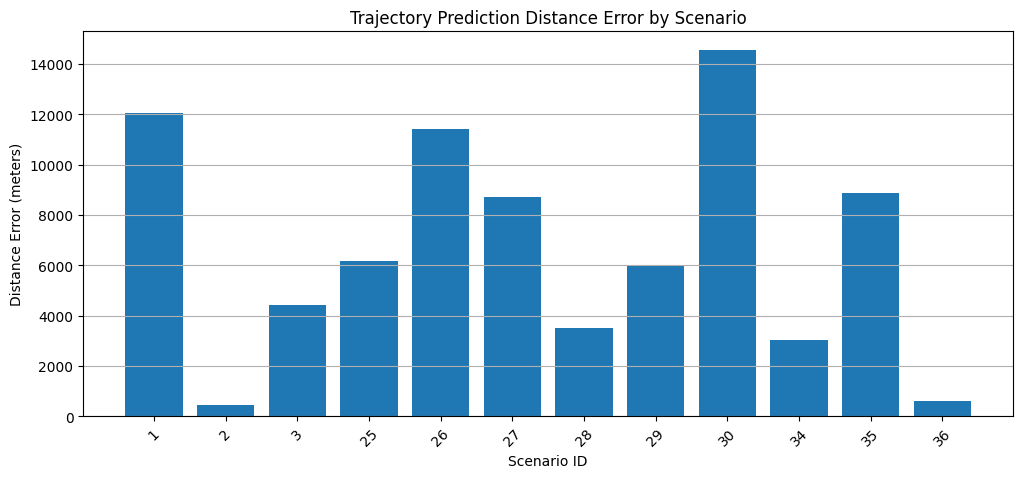

In [17]:
plt.figure(figsize=(12, 5))

x_labels = comparison_df["scenario_id"].astype(str)

plt.bar(x_labels, comparison_df["distance_error_m"])

plt.xlabel("Scenario ID")
plt.ylabel("Distance Error (meters)")
plt.title("Trajectory Prediction Distance Error by Scenario")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

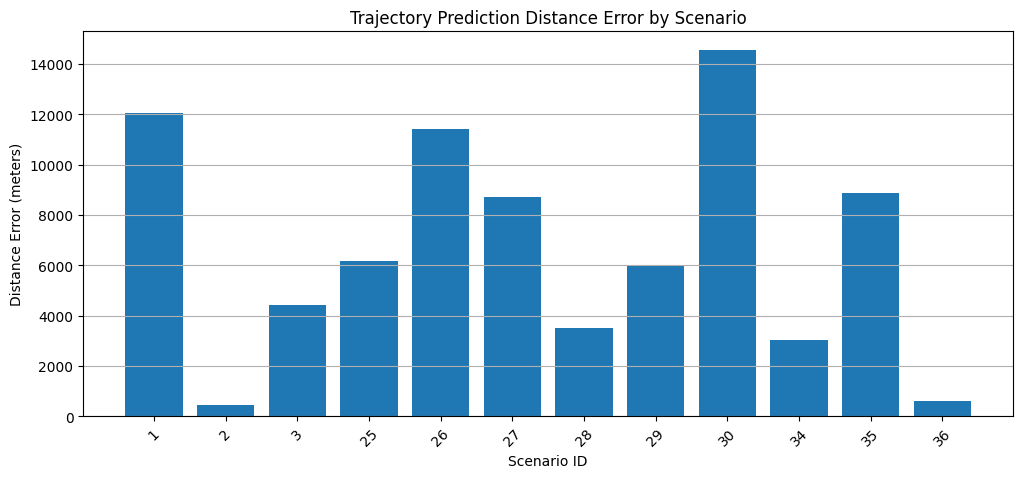

Saved error plot: /content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/trajectory_distance_error_chart.png


In [18]:
ERROR_PLOT_PATH = "/content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/trajectory_distance_error_chart.png"

plt.figure(figsize=(12, 5))

x_labels = comparison_df["scenario_id"].astype(str)

plt.bar(x_labels, comparison_df["distance_error_m"])

plt.xlabel("Scenario ID")
plt.ylabel("Distance Error (meters)")
plt.title("Trajectory Prediction Distance Error by Scenario")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.savefig(ERROR_PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved error plot:", ERROR_PLOT_PATH)

In [19]:
summary_result = pd.DataFrame([
    {
        "Metric": "MAE",
        "Value": 0.03859745776499872,
        "Unit": "degrees"
    },
    {
        "Metric": "RMSE",
        "Value": 0.05135330872935758,
        "Unit": "degrees"
    },
    {
        "Metric": "R2 Score",
        "Value": 0.52163067044691,
        "Unit": "-"
    },
    {
        "Metric": "Mean Distance Error",
        "Value": 6657.078951318603,
        "Unit": "meters"
    },
    {
        "Metric": "RMSE Distance Error",
        "Value": 7952.814003052021,
        "Unit": "meters"
    },
    {
        "Metric": "Minimum Distance Error",
        "Value": 469.52066183955174,
        "Unit": "meters"
    },
    {
        "Metric": "Maximum Distance Error",
        "Value": 14568.562643082561,
        "Unit": "meters"
    }
])

display(summary_result)

,Metric,Value,Unit
0,MAE,0.038597,degrees
1,RMSE,0.051353,degrees
2,R2 Score,0.521631,-
3,Mean Distance Error,6657.078951,meters
4,RMSE Distance Error,7952.814003,meters
5,Minimum Distance Error,469.520662,meters
6,Maximum Distance Error,14568.562643,meters


In [20]:
SUMMARY_CSV = "/content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/trajectory_model_evaluation_summary.csv"

summary_result.to_csv(SUMMARY_CSV, index=False)

print("Summary CSV saved:", SUMMARY_CSV)

Summary CSV saved: /content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/trajectory_model_evaluation_summary.csv
